In [13]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# 读取数据集
df = pd.read_csv(r"C:\DeskTop\小学期-机器学习\US-pumpkins.csv")

# 查看数据集的基本信息
df.shape

(1757, 26)

In [14]:
df.head()

,City Name,Type,Package,Variety,Sub Variety,Grade,Date,Low Price,High Price,Mostly Low,...,Unit of Sale,Quality,Condition,Appearance,Storage,Crop,Repack,Trans Mode,Unnamed: 24,Unnamed: 25
0,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,4/29/17,270.0,280.0,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
1,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,5/6/17,270.0,280.0,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
2,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
3,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
4,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,11/5/16,90.0,100.0,90.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN


In [15]:
# 检查缺失值情况
missing_values = df.isnull().sum()
print("\n各列缺失值数量：")
print(missing_values[missing_values > 0])


各列缺失值数量：
Type               1712
Variety               5
Sub Variety        1461
Grade              1757
Mostly Low          103
Mostly High         103
Origin                3
Origin District    1626
Item Size           279
Color               616
Environment        1757
Unit of Sale       1595
Quality            1757
Condition          1757
Appearance         1757
Storage            1757
Crop               1757
Trans Mode         1757
Unnamed: 24        1757
Unnamed: 25        1654
dtype: int64


In [22]:
# 删除缺失值过多的列
# 定义缺失值比例阈值
missing_threshold = 0.75  # 15%

# 删除缺失值比例超过阈值的列
cols_to_drop = df.columns[df.isnull().mean() > missing_threshold]
df = df.drop(cols_to_drop, axis=1)

# 查看删除后的缺失值情况
missing_values = df.isnull().sum()
print("\n删除后各列缺失值数量：")
print(missing_values[missing_values > 0])

df.shape


删除后各列缺失值数量：
Variety          5
Mostly Low     103
Mostly High    103
Origin           3
Item Size      279
Color          616
dtype: int64


(1757, 12)

In [23]:
# 填充缺失值
df['Variety'] = df['Variety'].fillna('unknown')
df['Origin'] = df['Origin'].fillna('unknown')
df['Item Size'] = df['Item Size'].fillna('unknown')
df['Color'] = df['Color'].fillna('unknown')

In [17]:
# 将价格列转换为数值类型（去除美元符号并转换为浮点数）
price_columns = ['Low Price', 'High Price', 'Mostly Low', 'Mostly High']
for col in price_columns:
    df[col] = df[col].replace({'\$': '', ',': ''}, regex=True).astype(float)

# 将日期列转换为日期类型
df['Date'] = pd.to_datetime(df['Date'])

In [24]:
df.head()

,City Name,Package,Variety,Date,Low Price,High Price,Mostly Low,Mostly High,Origin,Item Size,Color,Repack
0,BALTIMORE,24 inch bins,unknown,2017-04-29,270.0,280.0,270.0,280.0,MARYLAND,lge,unknown,E
1,BALTIMORE,24 inch bins,unknown,2017-05-06,270.0,280.0,270.0,280.0,MARYLAND,lge,unknown,E
2,BALTIMORE,24 inch bins,HOWDEN TYPE,2016-09-24,160.0,160.0,160.0,160.0,DELAWARE,med,ORANGE,N
3,BALTIMORE,24 inch bins,HOWDEN TYPE,2016-09-24,160.0,160.0,160.0,160.0,VIRGINIA,med,ORANGE,N
4,BALTIMORE,24 inch bins,HOWDEN TYPE,2016-11-05,90.0,100.0,90.0,100.0,MARYLAND,lge,ORANGE,N


In [29]:
# 识别分类变量列
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("分类变量列：", categorical_cols)

# 对分类变量进行独热编码
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print("独热编码后数据集形状：", df_encoded.shape)

# 查看编码后数据示例
print("\n独热编码后数据前5行：")
print(df_encoded.head())

分类变量列： ['City Name', 'Package', 'Variety', 'Origin', 'Item Size', 'Color', 'Repack']
独热编码后数据集形状： (1757, 80)

独热编码后数据前5行：
        Date  Low Price  High Price  Mostly Low  Mostly High  Year  Month  \
0 2017-04-29      270.0       280.0       270.0        280.0  2017      4   
1 2017-05-06      270.0       280.0       270.0        280.0  2017      5   
2 2016-09-24      160.0       160.0       160.0        160.0  2016      9   
3 2016-09-24      160.0       160.0       160.0        160.0  2016      9   
4 2016-11-05       90.0       100.0        90.0        100.0  2016     11   

   Day  Repack_encoded  City Name_BALTIMORE  ...  Item Size_lge  \
0   29               0                 True  ...           True   
1    6               0                 True  ...           True   
2   24               1                 True  ...          False   
3   24               1                 True  ...          False   
4    5               1                 True  ...           True   

   Item Size_

与High Price相关性强的特征：
High Price                    1.000000
Mostly High                   0.996174
Mostly Low                    0.989539
Low Price                     0.987353
Package_36 inch bins          0.433154
Package_24 inch bins          0.337257
City Name_BOSTON              0.303481
Package_1/2 bushel cartons   -0.504620
Variety_MINIATURE            -0.544909
Name: High Price, dtype: float64


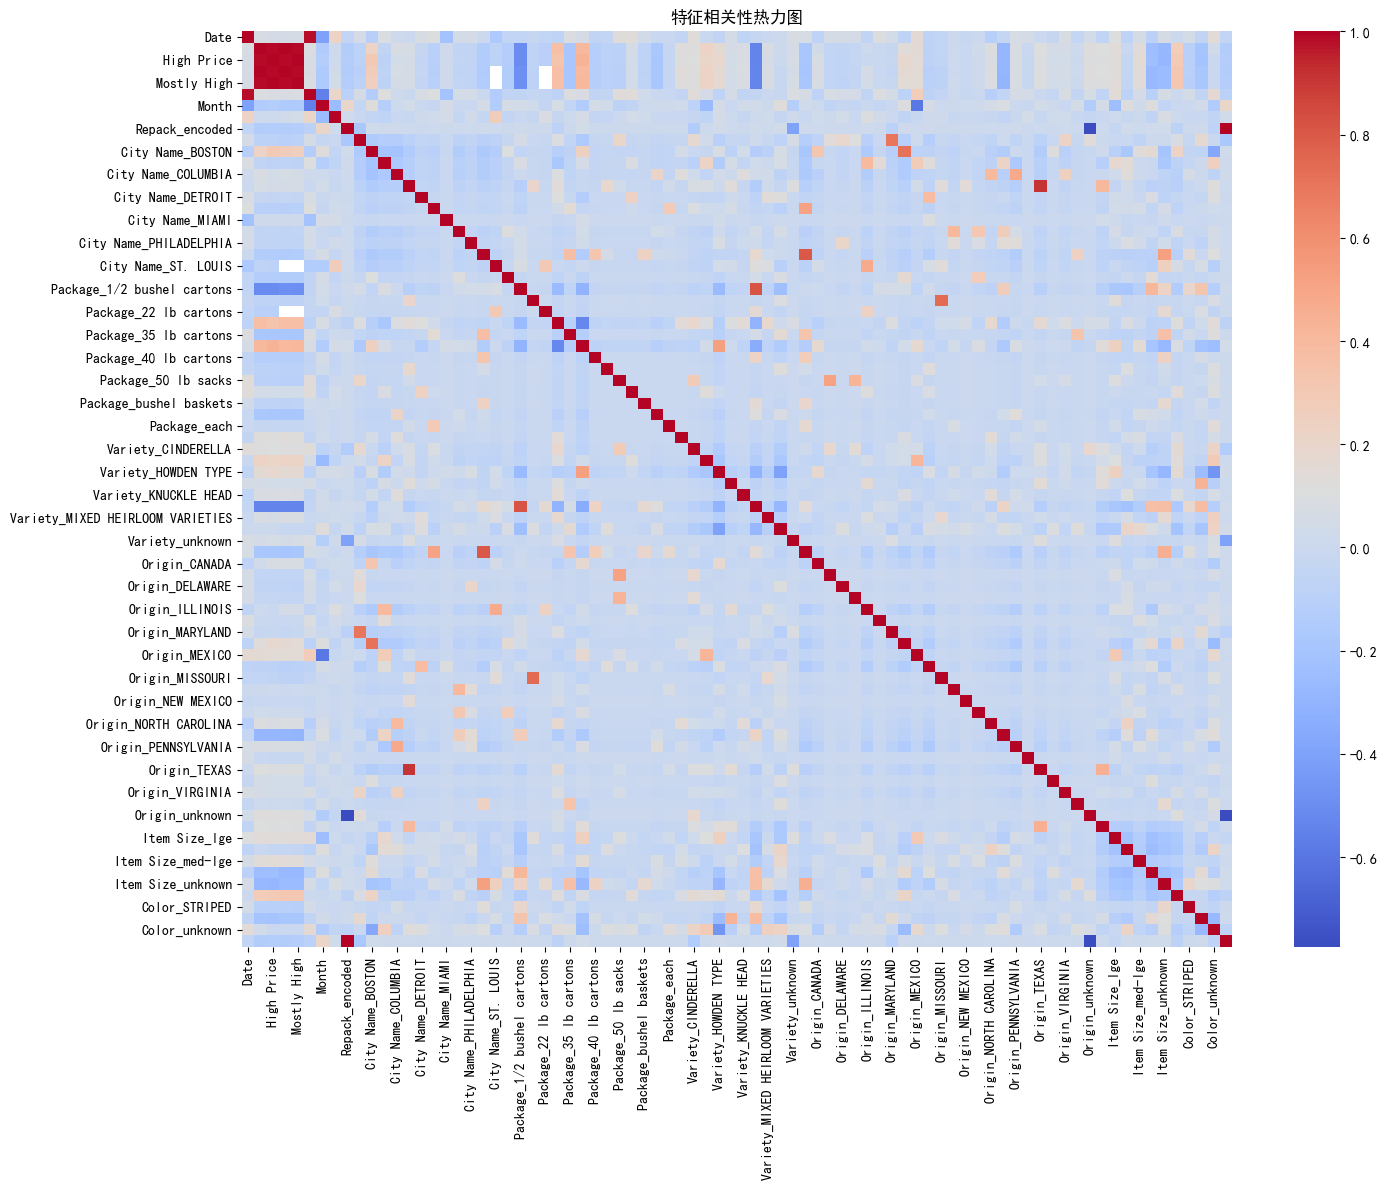

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False  

# 计算特征相关性矩阵
correlation = df_encoded.corr()

# 提取与价格相关的特征相关性
price_correlation = correlation['High Price'].sort_values(ascending=False)
print("与High Price相关性强的特征：")
print(price_correlation[abs(price_correlation) > 0.3])  

# 绘制相关性热力图
plt.figure(figsize=(15, 12))
sns.heatmap(correlation, annot=False, cmap='coolwarm', fmt='.2f')
plt.title('特征相关性热力图')
plt.tight_layout()
plt.show()

In [ ]:
# 选择与价格相关性强的特征
selected_features = ['Package_36 inch bins', 'Package_24 inch bins', 'City Name_BOSTON', 'Package_1/2 bushel cartons', 'Variety_MINIATURE']

# 准备特征和目标变量
X = df_encoded[selected_features]
y = df_encoded['High Price']

In [69]:
from sklearn.model_selection import train_test_split

# 重新划分训练集和测试集
X_train_imputed, X_test_imputed, y_train_imputed, y_test_imputed = train_test_split(X, y, test_size=0.2, random_state=42)

In [72]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score

# 定义模型列表
models = {
    '岭回归': Ridge(alpha=1.0),
    'Lasso回归': Lasso(alpha=0.1),
    '随机森林': RandomForestRegressor(n_estimators=100, random_state=42),
    '梯度提升树': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

# 定义模型评估函数
def evaluate_model(model, X_train, y_train, X_test, y_test):
    # 训练模型
    model.fit(X_train, y_train)
    
    # 预测
    y_pred = model.predict(X_test)
    
    # 计算评估指标
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    # 交叉验证
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error')
    cv_rmse = np.sqrt(-cv_scores).mean()
    
    return {
        '模型': model.__class__.__name__,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2,
        'CV_RMSE': cv_rmse
    }

# 评估每个模型
results = []
for name, model in models.items():
    result = evaluate_model(model, X_train_imputed, y_train_imputed, X_test_imputed, y_test_imputed)
    results.append(result)

# 显示模型评估结果
pd.DataFrame(results).sort_values('R²', ascending=False)

,模型,MSE,RMSE,MAE,R²,CV_RMSE
3,GradientBoostingRegressor,2549.236402,50.489963,32.648902,0.701124,53.384193
2,RandomForestRegressor,2650.827177,51.486184,33.206939,0.689213,54.207797
0,Ridge,2966.161479,54.462478,36.078976,0.652243,52.274397
1,Lasso,2974.083408,54.535158,35.968957,0.651314,52.290436


In [46]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 模型评估函数
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    # 训练集预测
    y_train_pred = model.predict(X_train)
    # 测试集预测
    y_test_pred = model.predict(X_test)
    
    # 计算评估指标
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    print(f"\n{model_name} 评估结果：")
    print(f"训练集 MSE: {train_mse:.4f}")
    print(f"测试集 MSE: {test_mse:.4f}")
    print(f"训练集 MAE: {train_mae:.4f}")
    print(f"测试集 MAE: {test_mae:.4f}")
    print(f"训练集 R²: {train_r2:.4f}")
    print(f"测试集 R²: {test_r2:.4f}")
    
    return y_test_pred


In [47]:
# 评估随机森林模型
rf_pred = evaluate_model(rf_model, X_train_scaled, y_train, X_test_scaled, y_test, "随机森林回归")

# 评估线性回归模型
lr_pred = evaluate_model(lr_model, X_train_scaled, y_train, X_test_scaled, y_test, "线性回归")


随机森林回归 评估结果：
训练集 MSE: 2382.8035
测试集 MSE: 2650.8272
训练集 MAE: 31.2710
测试集 MAE: 33.2069
训练集 R²: 0.6973
测试集 R²: 0.6892

线性回归 评估结果：
训练集 MSE: 2577.0210
测试集 MSE: 2961.5106
训练集 MAE: 33.7245
测试集 MAE: 36.0130
训练集 R²: 0.6726
测试集 R²: 0.6528


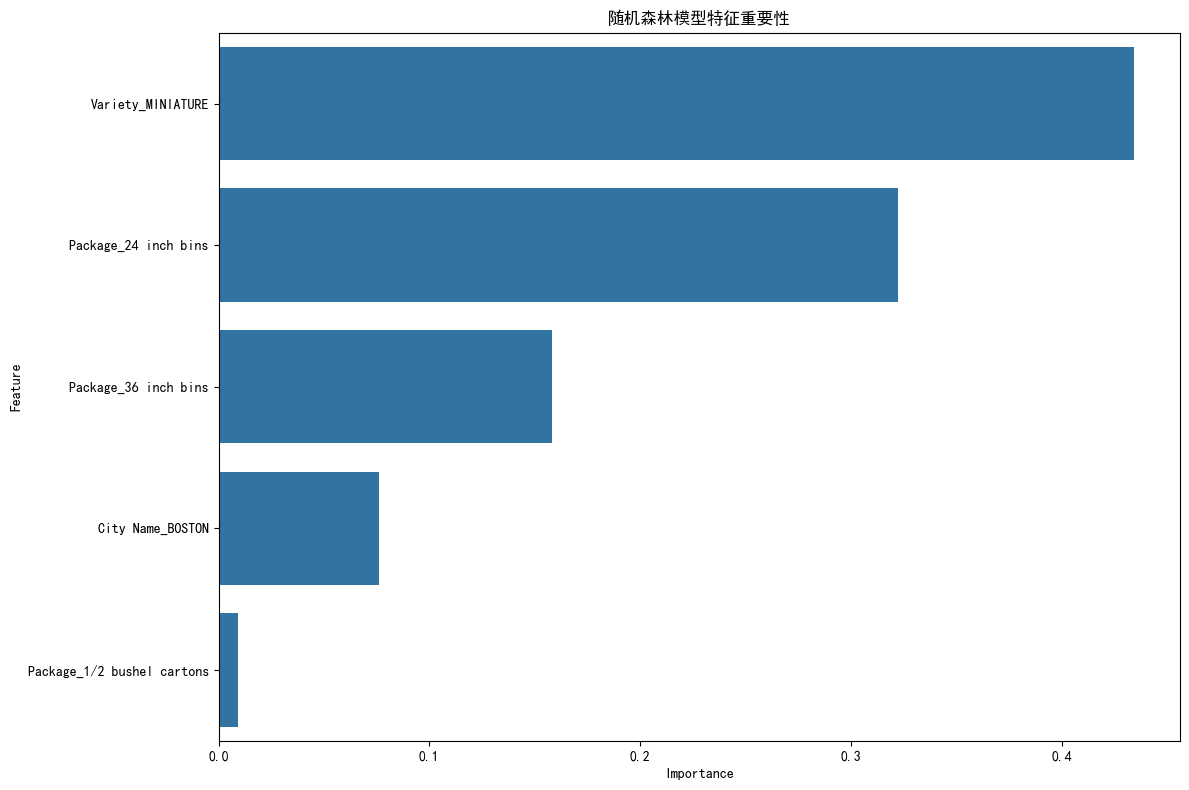


特征重要性排名（前10）：
                      Feature  Importance
4           Variety_MINIATURE    0.434284
2        Package_24 inch bins    0.322417
3        Package_36 inch bins    0.158116
0            City Name_BOSTON    0.075912
1  Package_1/2 bushel cartons    0.009270


In [48]:
# 特征重要性分析（随机森林模型）
if hasattr(rf_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'Feature': selected_features,
        'Importance': rf_model.feature_importances_
    })
    feature_importance = feature_importance.sort_values('Importance', ascending=False)
    
    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=feature_importance.head(10))
    plt.title('随机森林模型特征重要性')
    plt.tight_layout()
    plt.savefig('feature_importance.png')
    plt.show()
    
    print("\n特征重要性排名（前10）：")
    print(feature_importance.head(10))

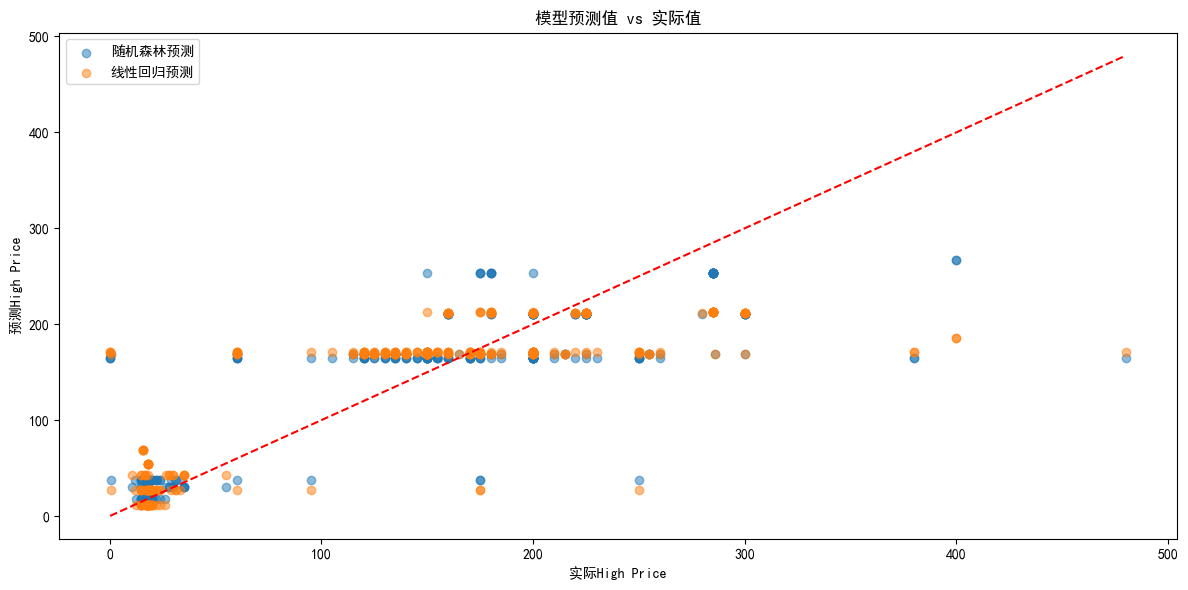

In [49]:
# 模型预测可视化
plt.figure(figsize=(12, 6))
plt.scatter(y_test, rf_pred, alpha=0.5, label='随机森林预测')
plt.scatter(y_test, lr_pred, alpha=0.5, label='线性回归预测')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel(f'实际{target_column}')
plt.ylabel(f'预测{target_column}')
plt.title(f'模型预测值 vs 实际值')
plt.legend()
plt.tight_layout()
plt.savefig('prediction_vs_actual.png')
plt.show()

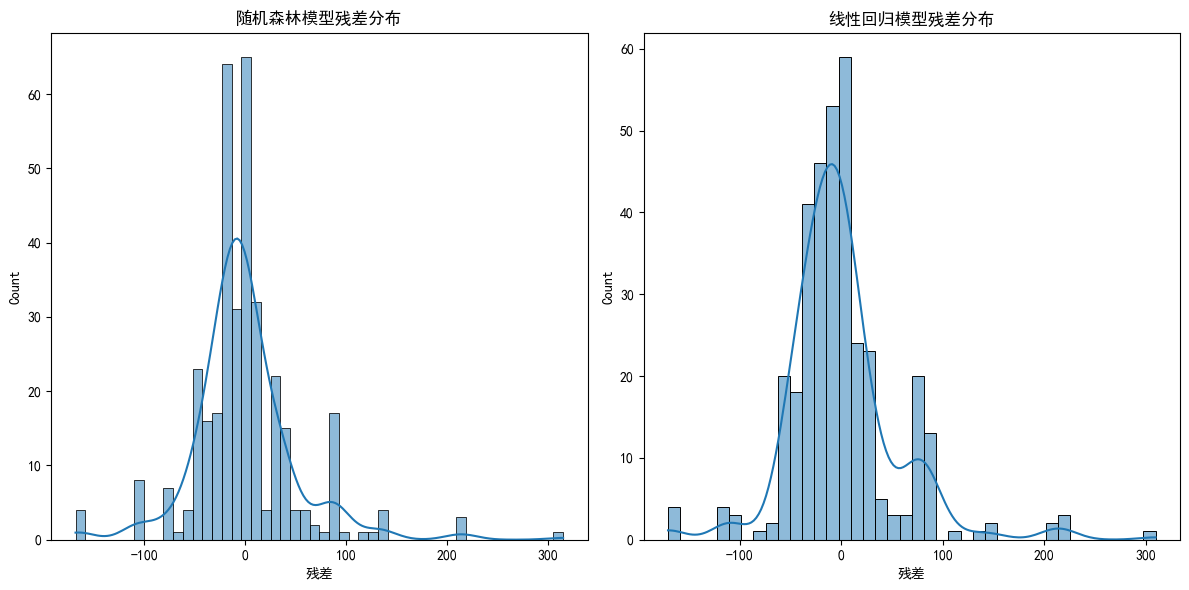

In [50]:
# 残差分析
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
residuals = y_test - rf_pred
sns.histplot(residuals, kde=True)
plt.title('随机森林模型残差分布')
plt.xlabel('残差')

plt.subplot(1, 2, 2)
residuals = y_test - lr_pred
sns.histplot(residuals, kde=True)
plt.title('线性回归模型残差分布')
plt.xlabel('残差')

plt.tight_layout()
plt.savefig('residual_distribution.png')
plt.show()

In [51]:
from sklearn.model_selection import GridSearchCV
# 超参数调优（随机森林）
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=5, scoring='r2')
grid_search.fit(X_train_scaled, y_train)

print("\n随机森林超参数调优最佳参数：")
print(grid_search.best_params_)
print(f"最佳交叉验证得分：{grid_search.best_score_:.4f}")


随机森林超参数调优最佳参数：
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}
最佳交叉验证得分：0.6868


In [52]:
# 使用最佳参数的模型评估
best_rf_model = grid_search.best_estimator_
best_rf_pred = best_rf_model.predict(X_test_scaled)
print("\n最佳参数随机森林模型评估：")
print(f"测试集 MSE: {mean_squared_error(y_test, best_rf_pred):.4f}")
print(f"测试集 MAE: {mean_absolute_error(y_test, best_rf_pred):.4f}")
print(f"测试集 R²: {r2_score(y_test, best_rf_pred):.4f}")


最佳参数随机森林模型评估：
测试集 MSE: 2657.7561
测试集 MAE: 33.2383
测试集 R²: 0.6884
